<img src="../workshops/img/swdb_logo.jpg">

<h1 align="center">Connectomics Exercise 1: Connection specificity</h1>
<h2 align="center">SOLUTIONS</h2>
<h3 align="center">Summer Workshop on the Dynamic Brain 2026</h3>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2> Preliminaries and imports </h2>
<p>The cells below set up the Common Connectivity dataset reader, load the proofread cells, synapses, and cell types, and import the helper functions (<code>filter_synapse_table</code>, <code>make_adjacency</code>) used throughout this exercise. These are straight out of Module 2, refer back to that for more information.

</div>

In [1]:
import sys
from os.path import join as pjoin
import os

# CodeOcean data asset and workshop utilities
mat_version = 1196
data_dir = f"/data/v1dd_{mat_version}_ccm"

project_id = "v1dd"
synapse_dataset_id = f"v1dd_{mat_version}_em"
synapse_feature_matrix_id = f"v1dd_{mat_version}_synapse_features"
axon_dataset_id = f"v1dd_{mat_version}_proofread_axons"
dendrite_dataset_id = f"v1dd_{mat_version}_proofread_dendrites"


# Robustly locate the utils directory regardless of the kernel's working directory.
for _candidate in [pjoin("..", "utils"), pjoin("code", "utils"), "utils"]:
    if os.path.isdir(_candidate):
        utils_dir = os.path.abspath(_candidate)
        break
else:
    raise FileNotFoundError(
        "Could not locate the 'utils' directory. Current working directory: "
        f"{os.getcwd()}"
    )

# Add utilities to path
sys.path.append(utils_dir)

In [2]:
# Import packages
from connects_common_connectivity.io import DatasetReader, read_synapse_table

import pandas as pd
import polars as pl
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from scipy.sparse import csr_array
from typing import Union, Optional

# note: we are importing some of the functions that you saw in Module 2
from utils import adjacencyplot, cell_type_palette, filter_synapse_table, make_adjacency

In [3]:
# Initialize the Common Connectivity dataset reader
reader = DatasetReader(data_dir)
reader.display_dataset_names() # see available cohorts

id,name,project_id,modality
str,str,str,str
"""v1dd_1196_em""","""V1DD release 1196 — EM somas""","""v1dd""","""ELECTRON_MICROSCOPY"""
"""v1dd_1196_proofread_axons""","""V1DD release 1196 — proofread …","""v1dd""","""ELECTRON_MICROSCOPY"""
"""v1dd_1196_proofread_dendrites""","""V1DD release 1196 — proofread …","""v1dd""","""ELECTRON_MICROSCOPY"""


In [4]:
# Loads cells with axon and dendrite proofreading
proofread_axons = reader.read_dataset(axon_dataset_id)
proofread_dendrites = reader.read_dataset(dendrite_dataset_id)

dendrite_proof_root_ids = proofread_dendrites[
    "dataitem_id"
].cast(pl.UInt64).to_numpy()
axon_proof_root_ids = proofread_axons["dataitem_id"].cast(pl.UInt64).to_numpy()

print(
    f"There are {len(dendrite_proof_root_ids)} cells with acceptable dendrites, and {len(axon_proof_root_ids)} cells with axon proofreading"
)

# get the ids of all proofread cells with both axon and dendrite proofreading
proof_root_ids = axon_proof_root_ids[
    np.isin(axon_proof_root_ids, dendrite_proof_root_ids)
]


There are 63986 cells with acceptable dendrites, and 1164 cells with axon proofreading


In [5]:
synapse_data = read_synapse_table(
    project_id,
    dataset_id=synapse_dataset_id,
    features=True,
    feature_matrix_id=synapse_feature_matrix_id,
    output_root=data_dir,
)


syn_df = (
    synapse_data.with_columns(
        pl.col("id").cast(pl.UInt64),
        pl.col("presynaptic_cell").cast(pl.UInt64),
        pl.col("postsynaptic_cell").cast(pl.UInt64),
    )
    .rename(
        {
            "presynaptic_cell": "pre_pt_root_id",
            "postsynaptic_cell": "post_pt_root_id",
        }
    )
    .select(
        [
            "id",
            "pre_pt_position_x",
            "pre_pt_position_y",
            "pre_pt_position_z",
            "post_pt_position_x",
            "post_pt_position_y",
            "post_pt_position_z",
            "ctr_pt_position_x",
            "ctr_pt_position_y",
            "ctr_pt_position_z",
            "size",
            "pre_pt_root_id",
            "post_pt_root_id",
        ]
    )
    .to_pandas()
)

print(syn_df.shape)
syn_df.set_index("id", inplace=True)
syn_df.head(3)

(8204497, 13)


,pre_pt_position_x,pre_pt_position_y,pre_pt_position_z,post_pt_position_x,post_pt_position_y,post_pt_position_z,ctr_pt_position_x,ctr_pt_position_y,ctr_pt_position_z,size,pre_pt_root_id,post_pt_root_id
id,,,,,,,,,,,,
354386968,758200.5,802316.1,304380.0,757861.0,802558.6,304650.0,757967.7,802597.4,304380.0,240,864691132536286810,864691132734919083
378070488,792063.2,514342.5,183735.0,792664.6,514284.3,183915.0,792412.4,514294.0,183735.0,3056,864691132572190492,864691132606767301
499493001,977071.3,390075.8,191340.0,976974.3,390104.9,190935.0,976838.5,390337.7,190935.0,1346,864691132573738810,864691132747578447


In [6]:
cell_df = (
    proofread_dendrites
    .select(
        pl.col("dataitem_id").cast(pl.UInt64).alias("pt_root_id"),
        pl.col("soma_voxel_x").alias("pt_position_x"),
        pl.col("soma_voxel_y").alias("pt_position_y"),
        pl.col("soma_voxel_z").alias("pt_position_z"),
        (pl.col("soma_transformed_x") * 1_000).alias("pt_position_trform_x"),
        (pl.col("soma_transformed_y") * 1_000).alias("pt_position_trform_y"),
        (pl.col("soma_transformed_z") * 1_000).alias("pt_position_trform_z"),
        pl.col("soma_volume").alias("volume"),
        pl.col("v1dd_cell_types_level_1").alias("cell_type_coarse"),
        pl.col("v1dd_cell_types_level_2").alias("cell_type"),
    )
    .to_pandas()
)
# Add a column that is soma depth in consistent units
cell_df['depth_um'] = cell_df['pt_position_trform_y'] / 1_000 # from nm to um

cell_df.head()

,pt_root_id,pt_position_x,pt_position_y,pt_position_z,pt_position_trform_x,pt_position_trform_y,pt_position_trform_z,volume,cell_type_coarse,cell_type,depth_um
0,864691132496108732,1655130.0,605358.0,776205.0,747656.000000,423467.96875,484288.125000,153.827026,None,None,423.467957
1,864691132511800666,1227399.0,659134.0,270000.0,338375.718750,340317.50000,-18482.541016,257.700134,None,None,340.317505
2,864691132525163794,1546956.0,533345.0,771210.0,655235.437500,351830.09375,498754.968750,258.204437,None,None,351.830109
3,864691132533275738,641054.0,609626.0,372420.0,-244824.640625,322760.31250,92315.421875,226.991959,E,L4-IT,322.760315
4,864691132533347418,805488.0,633759.0,299205.0,-80788.093750,325624.25000,15554.438477,217.654556,E,L4-IT,325.624237


In [7]:
# Filter the proofread ids for those with a known cell type
proof_root_ids = np.intersect1d(proof_root_ids, cell_df["pt_root_id"].values)

# Filter the cell type table for those with a proofread root id
proof_cell_df = cell_df.set_index("pt_root_id").loc[proof_root_ids]
proof_cell_df = proof_cell_df.query("cell_type.notna()")

# NOTE: the adjacency matrix will be sorted according to this dataframe's index, so
# we'll sort it by soma depth
proof_cell_df = proof_cell_df.sort_values("pt_position_trform_y")

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2> Connection specificity onto compartment types </h2>
<p>Up until now we have considered all synapses between any two cells, but different synapses target different compartments on the postsynaptic cell.</p>
    
<img src="../../../figures/sss-diagram.png" width="600">

<p>For example, it is common understanding that:
<ol>
<li>Synapses between excitatory and excitatory cells are onto spines.
<li>Synapses between inhibitory and excitatory cells are onto dendritic shafts.
<li>Synapses onto inhibitory cells are onto dendritic shafts.
<li>Basket cells target soma synapses.
</ol>
<p>Let's test this textbook understanding in the real data.

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

<p><b>Task: recreate the adjacency matrix plot from Module 2, but selected per target compartment</b>

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<p>To begin, we've loaded up the target structure information as a Pandas Series for you, indexed by synapse ID:

</div>

In [8]:
target_structure = (
    synapse_data.select(pl.col("id").cast(pl.UInt64), "synaptictargetlabel")
    .to_pandas()
    .set_index("id")["synaptictargetlabel"]
)
target_structure

id
354386968    shaft
378070488    shaft
499493001     None
119675985     None
220616943     None
             ...  
489487534    shaft
489987803    shaft
465370688    shaft
450289242    shaft
443283303    spine
Name: synaptictargetlabel, Length: 8204497, dtype: object

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<p>Note that not all synapses will have predictions associated with them!
<p>In the cell below, use Pandas to include the target structure as a new column in your synapse data frame.

</div>

In [9]:
# SOLN
syn_df['target_structure'] = target_structure
syn_df['target_structure'].value_counts()

target_structure
shaft    3827760
spine    2690607
soma      187919
Name: count, dtype: int64

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<p>Now, we are going to remake the <code>adjacencyplot</code> from Module 2, but showing only the connections for one type of target structure (spine, shaft, or soma) at a time.
<p>First, filter the synapse table to just connections among proofread cells:

</div>

In [10]:
# SOLN
proof_proof_syn_table = filter_synapse_table(
    syn_df, pre_root_ids=proof_root_ids, post_root_ids=proof_root_ids
).copy()


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<p>Then, filter down to just the synapses onto spine, and pass into <code>make_adjacency</code> to get your matrix to plot. The plotting code is repeated here for your convenience.

</div>

In [11]:
category = 'spine' # This is synapses onto spines
...
# SOLN
category_syns_df = proof_proof_syn_table.query(f"target_structure == '{category}'")
category_adjacency = make_adjacency(
    category_syns_df, source_cell_index=proof_cell_df, aggfunc="sum"
)

(<Axes: >, <utils.AxisGrid at 0x7ff3e2fa3dd0>)

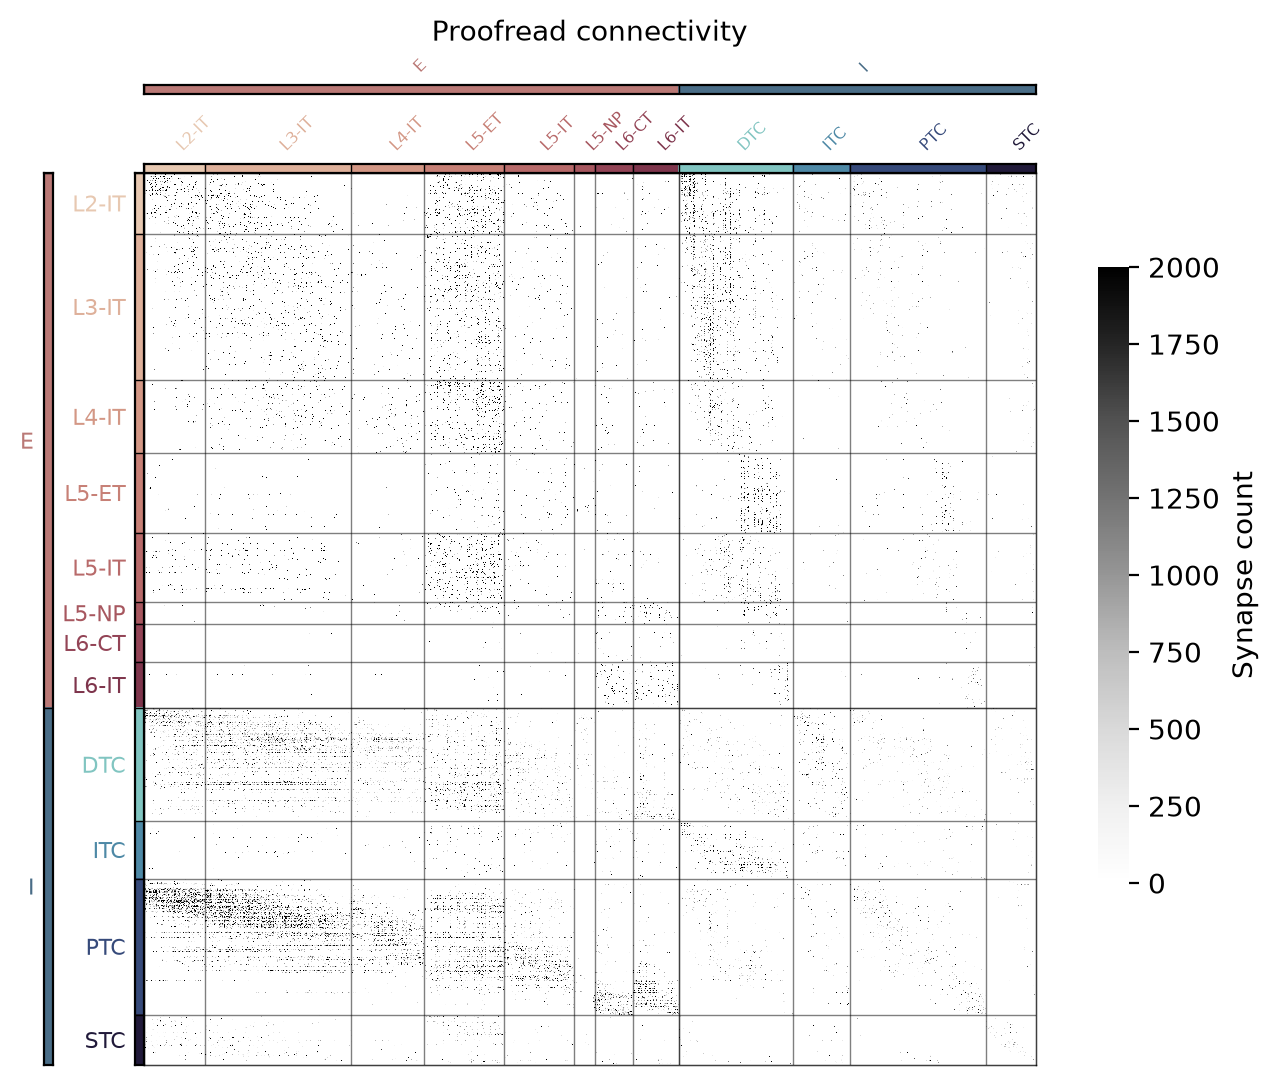

In [12]:
## Plot just synapses onto spine

fig, ax = plt.subplots(figsize=(8, 8), dpi=200)

# render the adjacency plot
adjacencyplot(
    category_adjacency,  
    nodes=proof_cell_df,  # data to organize the x and y axis
    groupby=["cell_type_coarse", "cell_type"],  # categorical variables to organize by
    sortby="pt_position_y",  # sort within groups by variable
    node_palette=cell_type_palette,
    title="Proofread connectivity",
    edge_palette="Greys",
    hue_norm=(0, 2000),  # normalize the color scale for the edges
    ax=ax,
    label_fontsize="xx-small",
    title_fontsize="medium",
    arc_labels=False
)


<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

<p><b>Task: Reproduce the plot above for <code>shaft</code> and <code>soma</code> instead of <code>spine</code>.</b>
<p>For loops or making a function may be helpful here!

</div>

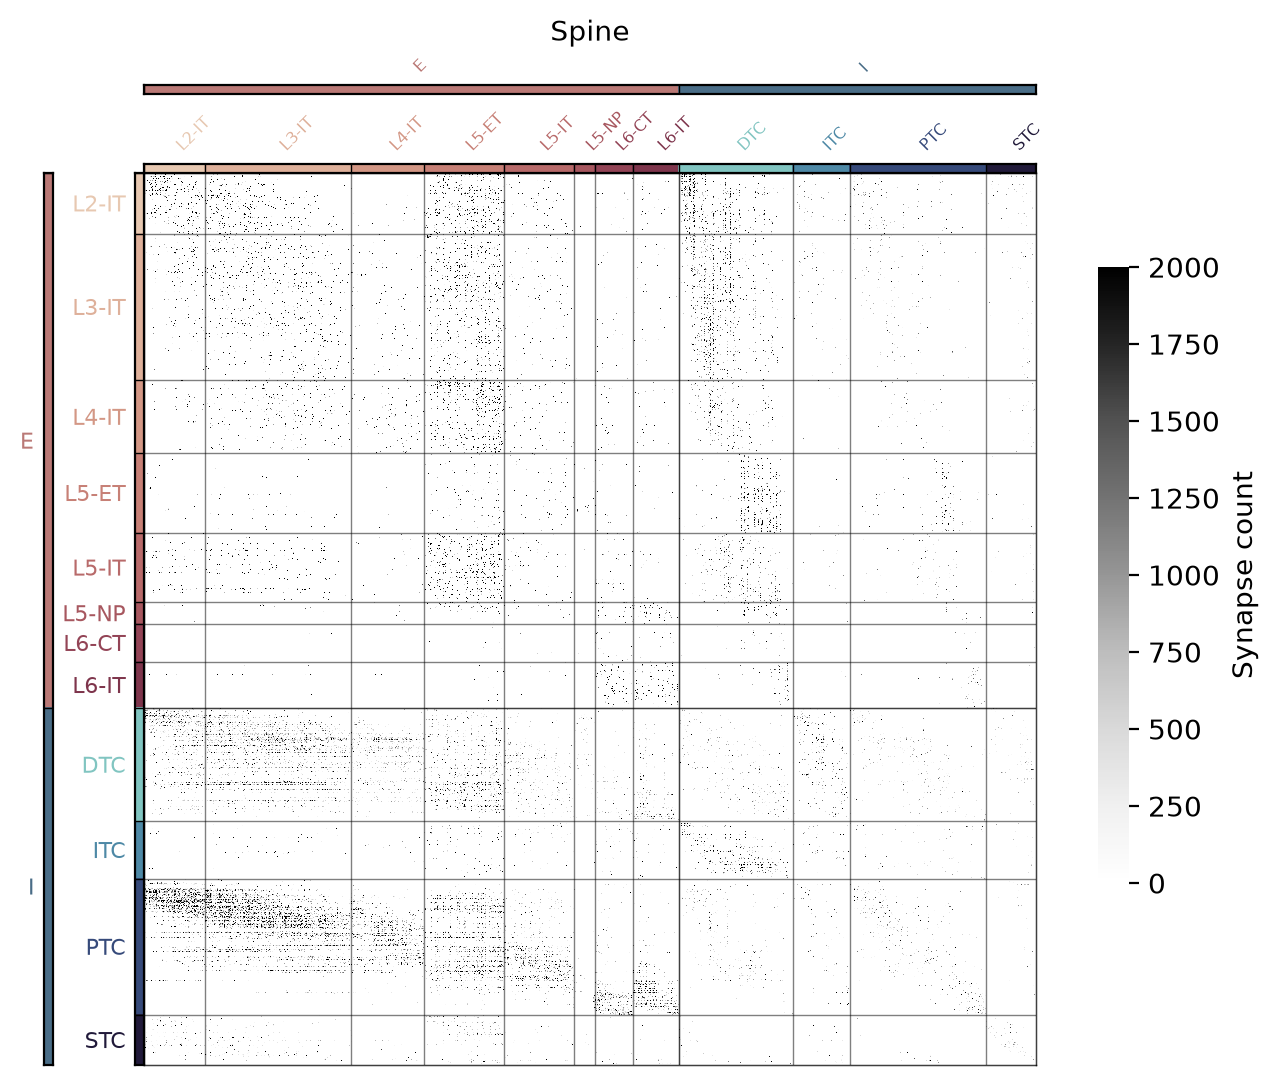

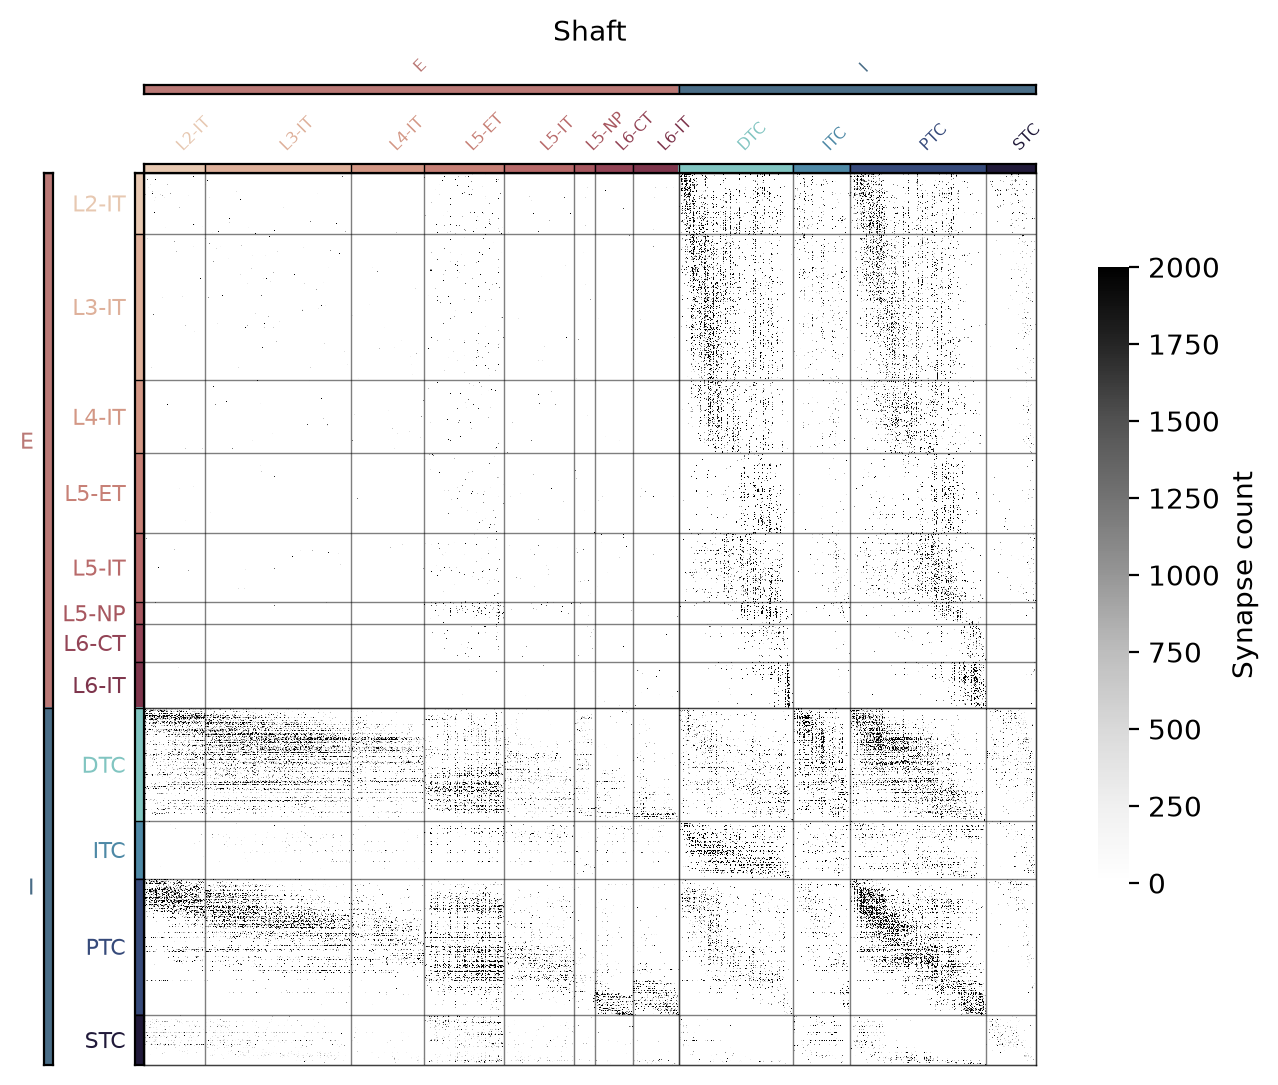

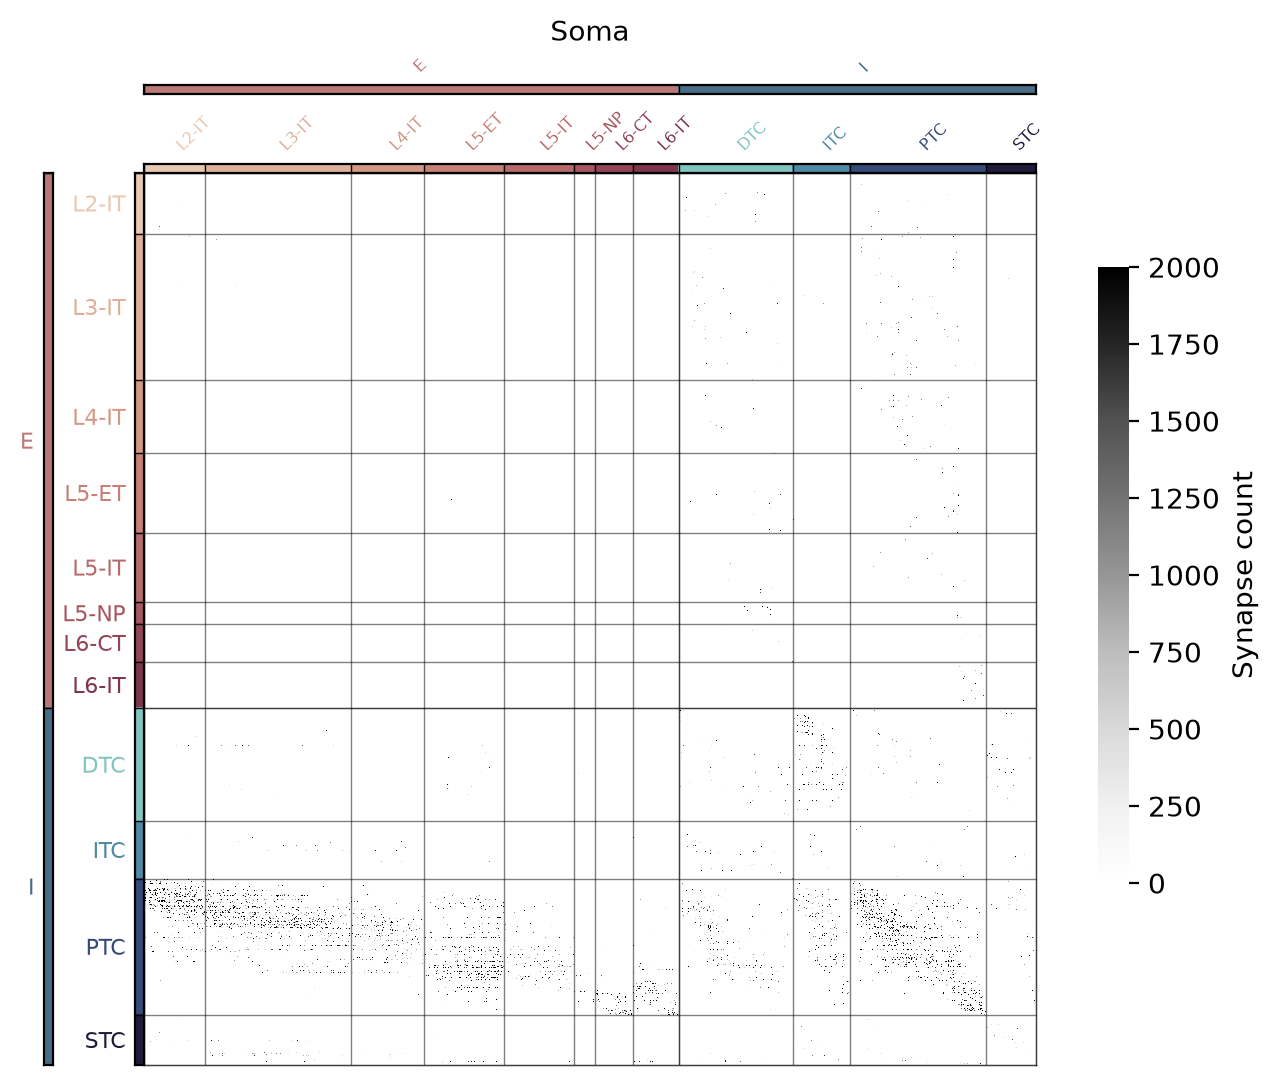

In [13]:
# SOLN

for category in ['spine', 'shaft', 'soma']:
    category_syns_df = proof_proof_syn_table.query(f"target_structure == '{category}'")
    category_adjacency = make_adjacency(
        category_syns_df, source_cell_index=proof_cell_df, aggfunc="sum"
    )
    
    fig, ax = plt.subplots(figsize=(8, 8), dpi=200)
    # render the adjacency plot
    adjacencyplot(
        category_adjacency ,  
        nodes=proof_cell_df,  # data to organize the x and y axis
        groupby=["cell_type_coarse", "cell_type"],  # categorical variables to organize by
        sortby="pt_position_y",  # sort within groups by variable
        node_palette=cell_type_palette,
        title=category.capitalize(),
        edge_palette="Greys",
        hue_norm=(0, 2000),  # normalize the color scale for the edges
        ax=ax,
        label_fontsize="xx-small",
        title_fontsize="medium",
        arc_labels=False
    )

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

<p><b>Discussion</b>
<p>For each of the common cell-type connectivity assumptions above, which hold up in the data?
<p>Find one thing that does not match your expectation and write it on the whiteboard.

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

<p><b>Bonus task: find highly spiny or non-spiny excitatory cells</b>
<p>Out of the excitatory cells in our proofread set, which receive the most of their synapses onto spines? Which receive the least?
<p>There are many ways to accomplish this, but Pandas <code>df.groupby()</code> will probably be your friend!

</div>

In [14]:
# SOLN

cell_p_per_target = syn_df.query('post_pt_root_id.isin(@proof_root_ids)').groupby("post_pt_root_id")['target_structure'].value_counts(normalize=True, dropna=True)
cell_p_per_target

post_pt_root_id     target_structure
864691132534275418  spine               0.780761
                    shaft               0.204698
                    soma                0.014541
864691132534315610  spine               0.681985
                    shaft               0.285846
                                          ...   
864691133313636944  shaft               0.232213
                    soma                0.012658
864691133313665616  spine               0.858195
                    shaft               0.130602
                    soma                0.011204
Name: proportion, Length: 3411, dtype: float64

In [15]:
# SOLN

cell_stats = cell_p_per_target.unstack(fill_value=0)
cell_stats

target_structure,shaft,soma,spine
post_pt_root_id,,,
864691132534275418,0.204698,0.014541,0.780761
864691132534315610,0.285846,0.032169,0.681985
864691132535664474,0.159420,0.010656,0.829923
864691132536286810,0.733834,0.015839,0.250327
864691132536904794,0.842414,0.008122,0.149464
...,...,...,...
864691133311980112,0.790280,0.029627,0.180093
864691133312850768,0.168246,0.015511,0.816243
864691133313558608,0.244458,0.025246,0.730296


In [16]:
# SOLN

proofread_cell_df = cell_df.reset_index().set_index("pt_root_id").loc[proof_root_ids].copy()
proofread_cell_df = proofread_cell_df.join(cell_stats)
proofread_cell_df

,index,pt_position_x,pt_position_y,pt_position_z,pt_position_trform_x,pt_position_trform_y,pt_position_trform_z,volume,cell_type_coarse,cell_type,depth_um,shaft,soma,spine
pt_root_id,,,,,,,,,,,,,,
864691132534275418,202,739373.0,633371.0,323640.0,-148078.156250,332191.125000,39439.652344,224.683212,E,L4-IT,332.191132,0.204698,0.014541,0.780761
864691132534315610,203,823103.0,635932.0,272970.0,-62356.000000,320556.312500,-10523.945312,236.639908,E,L4-IT,320.556305,0.285846,0.032169,0.681985
864691132535664474,221,972173.0,1006782.0,429480.0,-41442.625000,739148.875000,7655.985840,300.366089,E,L6-CT,739.148865,0.159420,0.010656,0.829923
864691132536286810,228,860041.0,818137.0,270495.0,-66701.281250,499937.656250,-63436.976562,278.909668,I,DTC,499.937653,0.733834,0.015839,0.250327
864691132536904794,240,940822.0,738674.0,146565.0,41854.175781,385942.062500,-158125.734375,273.808777,I,DTC,385.942078,0.842414,0.008122,0.149464
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
864691133311980112,63947,944004.0,468471.0,260910.0,77835.195312,152042.453125,-4724.690430,222.059601,I,ITC,152.042450,0.790280,0.029627,0.180093
864691133312850768,63954,881303.0,589838.0,217845.0,3956.872803,260341.546875,-56638.125000,389.688141,E,L3-IT,260.341553,0.168246,0.015511,0.816243
864691133313558608,63969,1022846.0,843590.0,229680.0,92688.406250,513292.312500,-110695.148438,333.575653,E,L5-IT,513.292297,0.244458,0.025246,0.730296


In [17]:
# SOLN

sorted_e_roots = proofread_cell_df.query("cell_type_coarse == 'E'").sort_values('spine',ascending=True).index
least_spiny = sorted_e_roots[0]
print("Least spiny:", least_spiny)
most_spiny = sorted_e_roots[-1]
print("Most spiny:", most_spiny)

proofread_cell_df.loc[most_spiny]

Least spiny: 864691132825909154
Most spiny: 864691132769830524


index                          39279
pt_position_x              1036426.0
pt_position_y               999643.0
pt_position_z               340110.0
pt_position_trform_x    36765.851562
pt_position_trform_y        705271.5
pt_position_trform_z    -71575.21875
volume                    392.541016
cell_type_coarse                   E
cell_type                      L6-IT
depth_um                  705.271484
shaft                       0.092921
soma                        0.009922
spine                       0.897157
Name: 864691132769830524, dtype: object

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

<p><b>Check our work! Find these cells in neuroglancer and compare them</b>
<p>Make sure what we've done makes sense! In what ways do these cells resemble each other morphologically? In what ways are they different?

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

<p><b>Bonus bonus task</b>
<p>How does the distribution of spine input vary for E vs I cells? Plot a histogram of proportion of spine input for E vs I cells.
<p>Hint: this is a one-liner with the right seaborn function.

</div>

<Axes: xlabel='spine', ylabel='Count'>

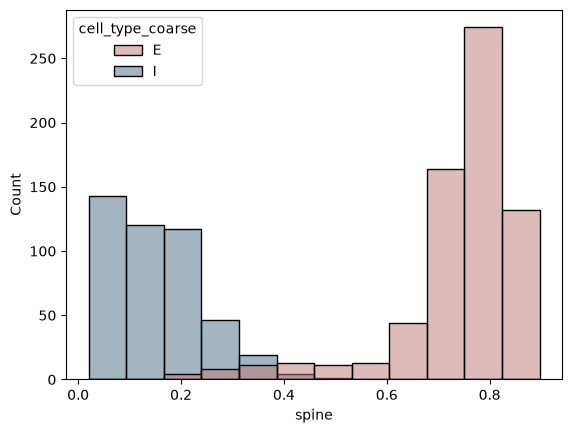

In [18]:
# SOLN

sns.histplot(data=proofread_cell_df, x='spine', hue='cell_type_coarse', palette=cell_type_palette)